In [42]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. 데이터 로드
df = pd.read_csv('winequality-red.csv')

print(df.head())


   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [43]:
# 2. 특성 선택
features = df.drop('quality', axis=1) 
target = df['quality']

In [44]:
# 3. 정규화 (표준화)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [45]:
# 4. K-Means 클러스터링
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_features)

print("\n클러스터별 개수")
print(df['cluster'].value_counts())


클러스터별 개수
cluster
0    722
1    502
2    375
Name: count, dtype: int64


In [46]:
# 5. 클러스터별 평균값 분석
cluster_mean = df.groupby('cluster').mean()
print("\n 클러스터별 평균값")
print(cluster_mean)


 클러스터별 평균값
         fixed acidity  volatile acidity  citric acid  residual sugar  \
cluster                                                                 
0             7.189889          0.609342     0.123047        2.214058   
1            10.067131          0.405080     0.469761        2.582570   
2             8.155467          0.535173     0.289680        3.105467   

         chlorides  free sulfur dioxide  total sulfur dioxide   density  \
cluster                                                                   
0         0.078553            13.507618             34.894737  0.995896   
1         0.100460            10.888446             30.627490  0.997574   
2         0.087235            27.108000             89.954667  0.997276   

               pH  sulphates    alcohol   quality  
cluster                                            
0        3.405762   0.609224  10.494044  5.552632  
1        3.195040   0.752131  10.724037  5.960159  
2        3.284267   0.626533   9.88315

In [47]:
# 6. 품질(quality)과의 관계 확인
print("\n 클러스터별 품질 평균")
cluster_mean['quality'] = df.groupby('cluster')['quality'].mean()
print(cluster_mean)


 클러스터별 품질 평균
         fixed acidity  volatile acidity  citric acid  residual sugar  \
cluster                                                                 
0             7.189889          0.609342     0.123047        2.214058   
1            10.067131          0.405080     0.469761        2.582570   
2             8.155467          0.535173     0.289680        3.105467   

         chlorides  free sulfur dioxide  total sulfur dioxide   density  \
cluster                                                                   
0         0.078553            13.507618             34.894737  0.995896   
1         0.100460            10.888446             30.627490  0.997574   
2         0.087235            27.108000             89.954667  0.997276   

               pH  sulphates    alcohol   quality  
cluster                                            
0        3.405762   0.609224  10.494044  5.552632  
1        3.195040   0.752131  10.724037  5.960159  
2        3.284267   0.626533   9.883

cluster 0(5.55), cluster 1(5.96),  cluster 2(5.36)  
quality는 1 > 0 > 2 순서를 보임  
cluster 0 : acidity, sugar 낮음
cluster 1 : acidity, citric acid, alcohol이 높으며 volatile acidity(잡맛요소) 낮음  
cluster 2 : residual sugar, sulfur dioxide, total sulfur dioxide(보존요소)가 매우 높으며 alcohol 낮음 - 낮은 품질 유추가능

In [48]:
# 7. PCA로 2차원 축소
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_features)

df['pca1'] = pca_result[:, 0]
df['pca2'] = pca_result[:, 1]

centroids = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)

c:\SK_Shieldus_Rookies\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


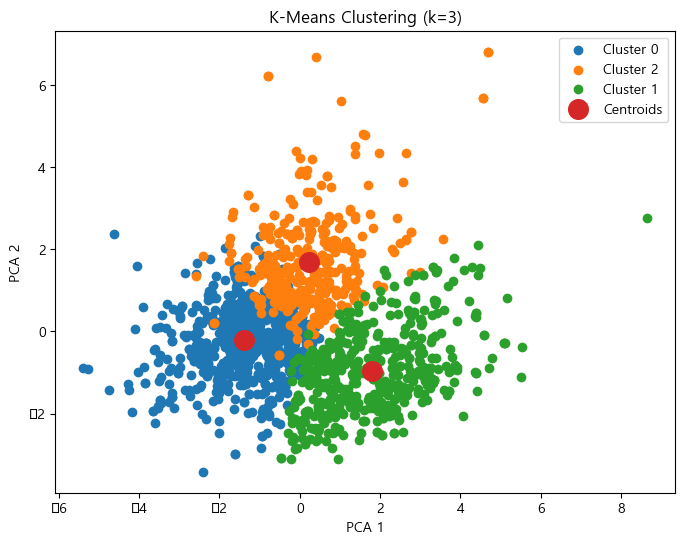

In [49]:
# 8. 시각화
plt.figure(figsize=(8,6))

for cluster in df['cluster'].unique():
    subset = df[df['cluster'] == cluster]
    plt.scatter(subset['pca1'], subset['pca2'], label=f'Cluster {cluster}')

plt.scatter(
    centroids_pca[:, 0], 
    centroids_pca[:, 1],
    marker='o',
    s=200,
    label='Centroids'
    )

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('K-Means Clustering (k=3)')
plt.legend()
plt.show()